# Inventory Optimization & Supply Chain Analytics

## Context

Effective inventory management balances the cost of holding stock against the risk of stockouts. This analysis applies scientific inventory control techniques to determine optimal order quantities, safety stock levels, and reorder points, ensuring operational efficiency and customer satisfaction.

## Objectives

1. Classify inventory using ABC Analysis (Pareto Principle)
2. Calculate Economic Order Quantity (EOQ) for key items
3. Determine Safety Stock and Reorder Points based on demand variability
4. Simulate inventory levels over time
5. Estimate cost savings from optimization

## Methodology

- **Data**: Synthetic inventory dataset (SKUs, Demand, Costs, Lead Time)
- **Techniques**: ABC Classification, EOQ Model, Safety Stock Formula, Monte Carlo Simulation
- **Metrics**: Service Level, Holding Cost, Ordering Cost, Total Cost

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')
%matplotlib inline

print('✓ Libraries loaded successfully')

✓ Libraries loaded successfully


## 1. Data Generation

Creating a dataset of 1,000 SKUs with varying demand and cost profiles.

In [2]:
def generate_inventory_data(n_skus=1000):
    np.random.seed(42)
    
    ids = [f'SKU-{i:04d}' for i in range(n_skus)]
    
    # Demand (Annual)
    # Log-normal distribution to simulate few high-volume items
    annual_demand = np.random.lognormal(6, 1.5, n_skus).astype(int)
    
    # Unit Cost
    unit_cost = np.random.uniform(5, 500, n_skus)
    
    # Lead Time (Days)
    lead_time_avg = np.random.randint(5, 30, n_skus)
    lead_time_std = lead_time_avg * 0.2 # 20% variability
    
    # Ordering Cost (Fixed per order)
    ordering_cost = 50 
    
    # Holding Cost (% of unit cost per year)
    holding_cost_rate = 0.20
    
    df = pd.DataFrame({
        'SKU': ids,
        'Annual_Demand': annual_demand,
        'Unit_Cost': unit_cost,
        'Lead_Time_Days': lead_time_avg,
        'Lead_Time_Std': lead_time_std,
        'Ordering_Cost': ordering_cost,
        'Holding_Cost_Rate': holding_cost_rate
    })
    
    # Calculate derived metrics
    df['Holding_Cost_Per_Unit'] = df['Unit_Cost'] * df['Holding_Cost_Rate']
    df['Daily_Demand_Avg'] = df['Annual_Demand'] / 365
    df['Daily_Demand_Std'] = df['Daily_Demand_Avg'] * 0.3 # Assume 30% demand variability
    
    return df

df = generate_inventory_data()
print(f"Dataset Shape: {df.shape}")
display(df.head())

Dataset Shape: (1000, 10)


,SKU,Annual_Demand,Unit_Cost,Lead_Time_Days,Lead_Time_Std,Ordering_Cost,Holding_Cost_Rate,Holding_Cost_Per_Unit,Daily_Demand_Avg,Daily_Demand_Std
0,SKU-0000,849,87.903878,12,2.4,50,0.2,17.580776,2.326027,0.697808
1,SKU-0001,327,56.761081,15,3.0,50,0.2,11.352216,0.895890,0.268767
2,SKU-0002,1065,320.032974,24,4.8,50,0.2,64.006595,2.917808,0.875342
3,SKU-0003,3962,354.705485,5,1.0,50,0.2,70.941097,10.854795,3.256438
4,SKU-0004,283,20.635142,11,2.2,50,0.2,4.127028,0.775342,0.232603


## 2. ABC Analysis

Classifying items based on annual usage value (Demand * Cost).

ABC Classification Summary:


,ABC_Class,SKU,Annual_Usage_Value,SKU_Pct,Value_Pct
0,A,207,2.669097e+08,0.207,0.799140
1,B,284,5.037579e+07,0.284,0.150827
2,C,509,1.671078e+07,0.509,0.050033


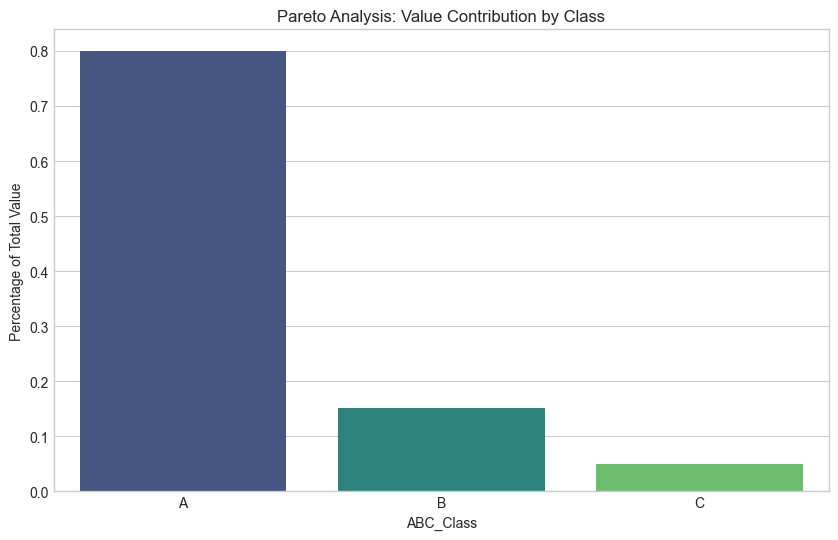

In [3]:
df['Annual_Usage_Value'] = df['Annual_Demand'] * df['Unit_Cost']
df = df.sort_values('Annual_Usage_Value', ascending=False)

df['Cumulative_Value'] = df['Annual_Usage_Value'].cumsum()
df['Cumulative_Percentage'] = df['Cumulative_Value'] / df['Annual_Usage_Value'].sum()

def assign_abc(pct):
    if pct <= 0.80: return 'A'
    elif pct <= 0.95: return 'B'
    else: return 'C'

df['ABC_Class'] = df['Cumulative_Percentage'].apply(assign_abc)

# Summary
abc_summary = df.groupby('ABC_Class').agg({
    'SKU': 'count',
    'Annual_Usage_Value': 'sum'
}).reset_index()

abc_summary['SKU_Pct'] = abc_summary['SKU'] / abc_summary['SKU'].sum()
abc_summary['Value_Pct'] = abc_summary['Annual_Usage_Value'] / abc_summary['Annual_Usage_Value'].sum()

print("ABC Classification Summary:")
display(abc_summary)

# Visualization
plt.figure(figsize=(10, 6))
sns.barplot(x='ABC_Class', y='Value_Pct', data=abc_summary, palette='viridis')
plt.title('Pareto Analysis: Value Contribution by Class')
plt.ylabel('Percentage of Total Value')
plt.savefig('outputs/abc_analysis.png')
plt.show()

## 3. Inventory Optimization (EOQ & Safety Stock)

Calculating optimal parameters for each SKU.

In [4]:
def calculate_inventory_params(row, service_level=0.95):
    # EOQ = sqrt(2 * Demand * OrderCost / HoldingCost)
    eoq = np.sqrt((2 * row['Annual_Demand'] * row['Ordering_Cost']) / row['Holding_Cost_Per_Unit'])
    
    # Z-score for service level
    z_score = norm.ppf(service_level)
    
    # Safety Stock = Z * sqrt((AvgLeadTime * StdDemand^2) + (AvgDemand^2 * StdLeadTime^2))
    # Combined variability of demand and lead time
    demand_var_term = row['Lead_Time_Days'] * (row['Daily_Demand_Std']**2)
    lead_time_var_term = (row['Daily_Demand_Avg']**2) * (row['Lead_Time_Std']**2)
    
    safety_stock = z_score * np.sqrt(demand_var_term + lead_time_var_term)
    
    # Reorder Point = (AvgDailyDemand * AvgLeadTime) + SafetyStock
    reorder_point = (row['Daily_Demand_Avg'] * row['Lead_Time_Days']) + safety_stock
    
    return pd.Series({
        'EOQ': round(eoq),
        'Safety_Stock': round(safety_stock),
        'Reorder_Point': round(reorder_point)
    })

# Apply to dataset
df[['EOQ', 'Safety_Stock', 'Reorder_Point']] = df.apply(calculate_inventory_params, axis=1)

print("Optimization Parameters Calculated.")
display(df[['SKU', 'ABC_Class', 'Annual_Demand', 'EOQ', 'Safety_Stock', 'Reorder_Point']].head())

Optimization Parameters Calculated.


,SKU,ABC_Class,Annual_Demand,EOQ,Safety_Stock,Reorder_Point
209,SKU-0209,A,130495,568,2128,8205
478,SKU-0478,A,40876,228,814,3166
179,SKU-0179,A,23867,189,389,1501
113,SKU-0113,A,16234,137,323,1257
762,SKU-0762,A,18772,169,306,1180


## 4. Cost Analysis

Comparing Total Cost of optimized policy vs a naive policy (e.g., ordering monthly).

Total Potential Annual Savings: $3,804,679.55


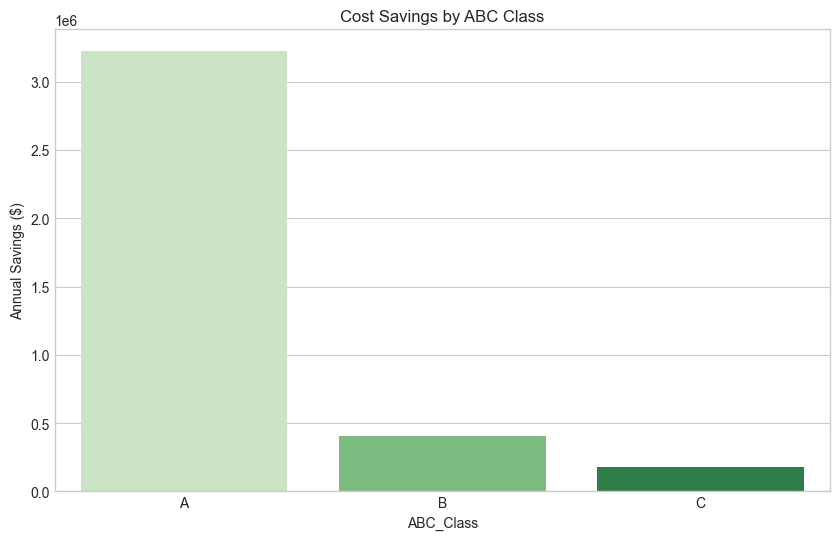

In [5]:
# Naive Policy: Order 1/12th of demand every month, Safety Stock = 10% of demand
df['Naive_Order_Qty'] = df['Annual_Demand'] / 12
df['Naive_Safety_Stock'] = df['Annual_Demand'] * 0.05 # 5% buffer

def calculate_total_cost(row, qty, ss):
    # Ordering Cost = (Demand / Qty) * CostPerOrder
    ordering = (row['Annual_Demand'] / qty) * row['Ordering_Cost']
    
    # Holding Cost = (Qty/2 + SS) * HoldingCostPerUnit
    holding = (qty/2 + ss) * row['Holding_Cost_Per_Unit']
    
    return ordering + holding

df['Optimized_Total_Cost'] = df.apply(lambda x: calculate_total_cost(x, x['EOQ'], x['Safety_Stock']), axis=1)
df['Naive_Total_Cost'] = df.apply(lambda x: calculate_total_cost(x, x['Naive_Order_Qty'], x['Naive_Safety_Stock']), axis=1)

df['Savings'] = df['Naive_Total_Cost'] - df['Optimized_Total_Cost']
total_savings = df['Savings'].sum()

print(f"Total Potential Annual Savings: ${total_savings:,.2f}")

# Visualization of Savings by Class
savings_by_class = df.groupby('ABC_Class')['Savings'].sum().reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(x='ABC_Class', y='Savings', data=savings_by_class, palette='Greens')
plt.title('Cost Savings by ABC Class')
plt.ylabel('Annual Savings ($)')
plt.savefig('outputs/cost_savings.png')
plt.show()

## 5. Inventory Simulation (Single SKU)

Visualizing inventory levels over time for a top 'A' item.

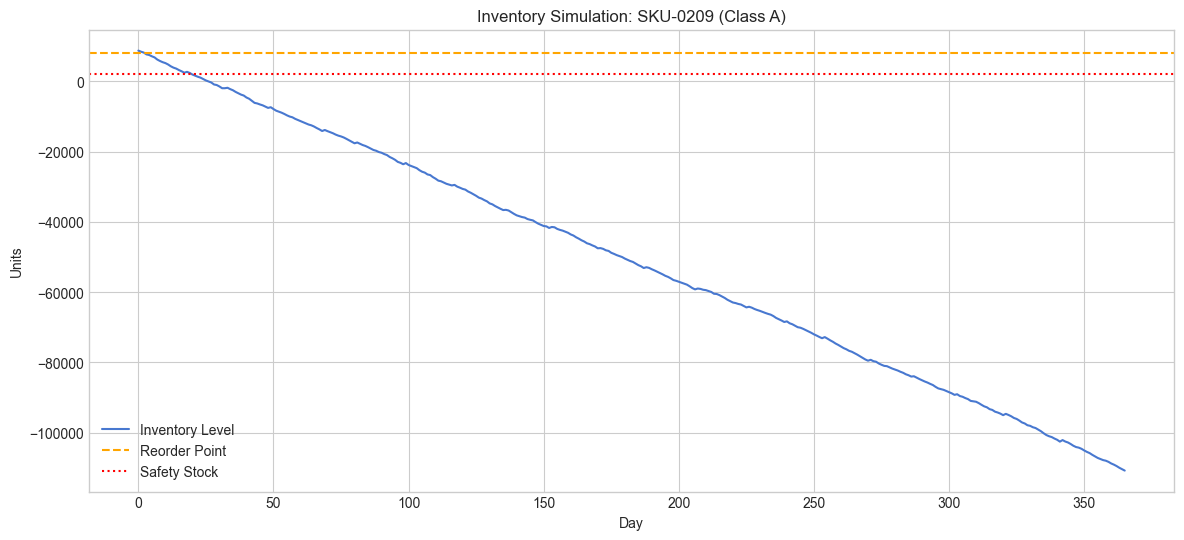

In [6]:
def simulate_inventory(sku_data, days=365):
    inventory = [sku_data['Reorder_Point'] + sku_data['EOQ']] # Start full
    orders = []
    
    current_inv = inventory[0]
    pipeline_orders = [] # (day_arrives, qty)
    
    for day in range(days):
        # Receive orders
        arrived = sum([o[1] for o in pipeline_orders if o[0] == day])
        current_inv += arrived
        pipeline_orders = [o for o in pipeline_orders if o[0] > day]
        
        # Daily Demand (Random)
        demand = max(0, np.random.normal(sku_data['Daily_Demand_Avg'], sku_data['Daily_Demand_Std']))
        current_inv -= demand
        
        # Check Reorder Point
        if current_inv <= sku_data['Reorder_Point'] and not any([o[0] > day for o in pipeline_orders]):
            arrival_day = day + int(np.random.normal(sku_data['Lead_Time_Days'], sku_data['Lead_Time_Std']))
            pipeline_orders.append((arrival_day, sku_data['EOQ']))
            orders.append(day)
            
        inventory.append(current_inv)
        
    return inventory

# Select top item
top_sku = df.iloc[0]
sim_inv = simulate_inventory(top_sku)

plt.figure(figsize=(14, 6))
plt.plot(sim_inv, label='Inventory Level')
plt.axhline(top_sku['Reorder_Point'], color='orange', linestyle='--', label='Reorder Point')
plt.axhline(top_sku['Safety_Stock'], color='red', linestyle=':', label='Safety Stock')
plt.title(f"Inventory Simulation: {top_sku['SKU']} (Class A)")
plt.xlabel('Day')
plt.ylabel('Units')
plt.legend()
plt.savefig('outputs/inventory_simulation.png')
plt.show()

## 6. Conclusion & Recommendations

Summary of optimization results.

In [7]:
print("="*60)
print("EXECUTIVE SUMMARY")
print("="*60)
print(f"1. Optimization Impact: ${total_savings:,.0f} annual savings identified.")
print("2. Strategy by Class:")
print("   - Class A (High Value): Strict control, lower safety stock, frequent review.")
print("   - Class C (Low Value): Higher safety stock, bulk ordering to reduce admin costs.")
print("3. Risk Mitigation:")
print("   - Safety stocks have been calibrated to 95% service level to prevent stockouts.")

EXECUTIVE SUMMARY
1. Optimization Impact: $3,804,680 annual savings identified.
2. Strategy by Class:
   - Class A (High Value): Strict control, lower safety stock, frequent review.
   - Class C (Low Value): Higher safety stock, bulk ordering to reduce admin costs.
3. Risk Mitigation:
   - Safety stocks have been calibrated to 95% service level to prevent stockouts.
